# Firewall rule classification 

# Objective 
## Develop a machine learning model for classifying firewall rules into different categories such as Allow, Drop, and Deny:

### Why is automating the classification of firewall rules using machine learning beneficial?
#### . Efficiency and Speed
* Efficiency and Speed

    * Manual Classification is Time-Consuming: Firewall rules can number in the thousands, and manually classifying and auditing them takes considerable time. Machine learning models can quickly classify and group rules based on patterns or similarities, reducing the time spent on routine tasks.

    * Continuous Monitoring and Updates: As networks evolve and new rules are added, ML systems can continually learn and adapt to classify new rules without requiring a full manual review each time.

* Error Reduction



*  Enhanced Security

    * Anomaly Detection: ML models can help identify unusual or anomalous rules that don't conform to best practices or the typical behavior of the network. This could include overly permissive rules or misconfigurations that may introduce vulnerabilities.










In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns
import itertools


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
     


In [3]:
import pandas as pd

df = pd.read_csv('~/Desktop/Firewall_Rule_Classification.csv')
df.shape

(262128, 12)

# Below we will analyze the dataset
## Provide a brief overview of the dataset, including the features it contains

### There are a total of 12 columns and a total of 262128 rows. 
*    allow         150314
*    deny           60053
*    drop           51539
*   reset-both       222*

#### we need to use LabelEncoder to convert the categorical "Class" column into numerical values. This transformation will make it easier for the Machine Learning models we plan to use to process the data effectively.



In [10]:

df.columns
     


Index(['Source Port', 'Destination Port', 'NAT Source Port',
       'NAT Destination Port', 'Bytes', 'Bytes Sent', 'Bytes Received',
       'Packets', 'Elapsed Time (sec)', 'pkts_sent', 'pkts_received', 'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262128 entries, 0 to 262127
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Source Port           262128 non-null  int64 
 1   Destination Port      262128 non-null  int64 
 2   NAT Source Port       262128 non-null  int64 
 3   NAT Destination Port  262128 non-null  int64 
 4   Bytes                 262128 non-null  int64 
 5   Bytes Sent            262128 non-null  int64 
 6   Bytes Received        262128 non-null  int64 
 7   Packets               262128 non-null  int64 
 8   Elapsed Time (sec)    262128 non-null  int64 
 9   pkts_sent             262128 non-null  int64 
 10  pkts_received         262128 non-null  int64 
 11  Class                 262128 non-null  object
dtypes: int64(11), object(1)
memory usage: 24.0+ MB


In [9]:

# Analyzing the dataset
df['Class'].value_counts()
     


Class
allow         150314
deny           60053
drop           51539
reset-both       222
Name: count, dtype: int64

In [11]:
df.describe()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,262128.000000,262128.000000,262128.000000,262128.000000,2.621280e+05,2.621280e+05,2.621280e+05,2.621280e+05,262128.000000,262128.000000,262128.000000
mean,49351.107871,10623.147405,19235.550143,2672.552829,1.031905e+05,2.487492e+04,7.831556e+04,1.058449e+02,65.457692,42.998096,62.846808
std,15259.968678,18509.668217,21951.947307,9749.041160,6.107068e+06,4.218560e+06,2.645716e+06,5.311349e+03,299.143576,3443.733023,2207.327701
min,0.000000,0.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
25%,49174.000000,80.000000,0.000000,0.000000,6.600000e+01,6.600000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
50%,53763.000000,445.000000,8740.000000,53.000000,1.680000e+02,9.000000e+01,7.900000e+01,2.000000e+00,15.000000,1.000000,1.000000
75%,58638.000000,15000.000000,38160.000000,443.000000,7.540000e+02,2.140000e+02,4.520000e+02,6.000000e+00,30.000000,3.000000,2.000000
max,65534.000000,65535.000000,65535.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000


In [12]:
df.fillna(method="ffill", inplace=True)

/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_1293/173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


# Visualization: 
## 1. Pie chart


<Axes: ylabel='count'>

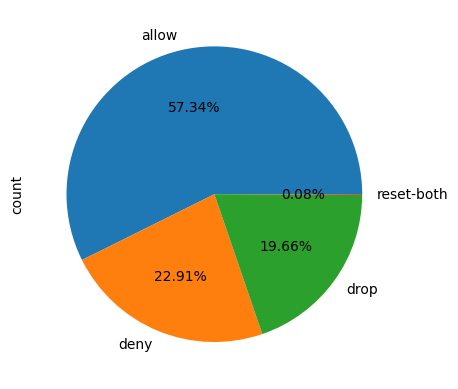

In [13]:
df["Class"].value_counts().plot(kind="pie", autopct="%.2f%%")

# 2. Heatmap 

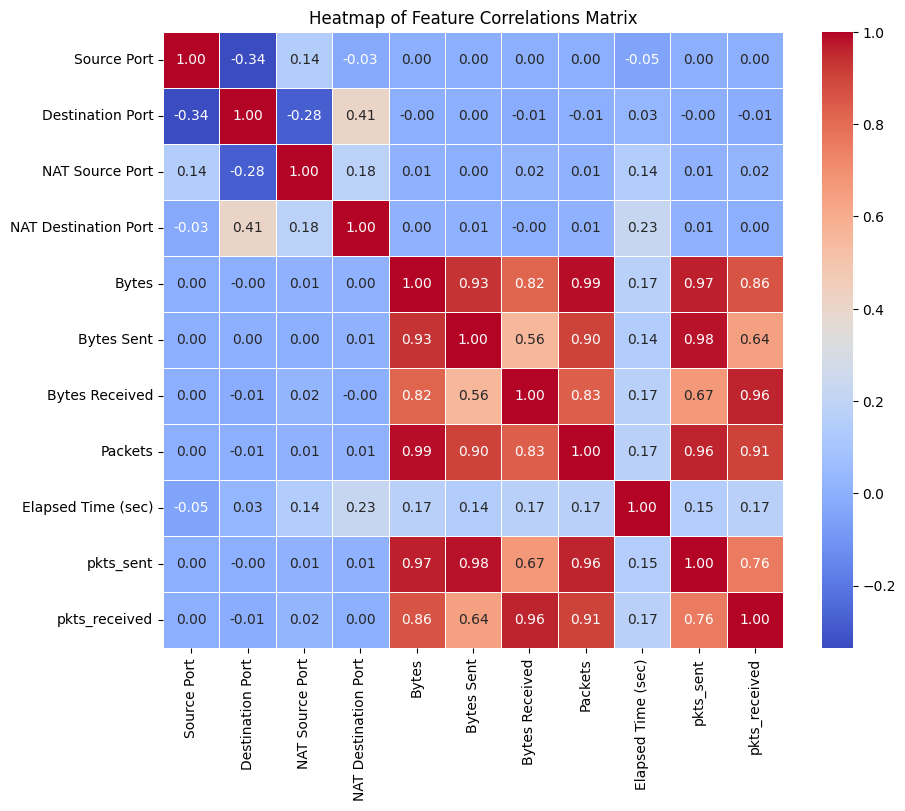

In [20]:

new_df = df.select_dtypes(include=['int64', 'float64'])

if "class" in new_df.columns:
    new_df.drop(columns=["class"], inplace=True)


matrix_df = new_df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(matrix_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Feature Correlations Matrix")
plt.show()

In [24]:

upper = matrix_df.abs().where(np.triu(np.ones_like(matrix_df, dtype=bool), k=1))


top_correlation = (upper.unstack()
    .sort_values(ascending=False)
    .reset_index()
    .query('level_0 != level_1')
    .drop_duplicates(subset=['level_0', 'level_1'])
    .head(5))


top_correlation.columns = ['Variable 1', 'Variable 2', 'correlation']

print("Top 5 Feature Correlations:")
print(top_correlation)

Top 5 Feature Correlations:
      Variable 1      Variable 2  correlation
0        Packets           Bytes     0.985089
1      pkts_sent      Bytes Sent     0.980635
2      pkts_sent           Bytes     0.967809
3      pkts_sent         Packets     0.962159
4  pkts_received  Bytes Received     0.959234


/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_1293/1576176229.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', order=classes, palette=color)


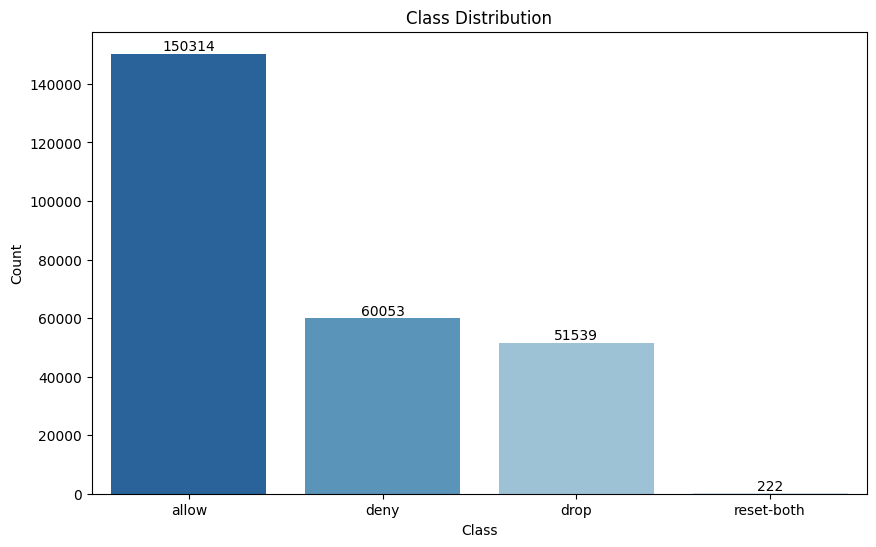

In [27]:

class_value = df['Class'].value_counts().sort_values(ascending=False)
classes = class_value.index


color= sns.color_palette("Blues", len(classes))[::-1]


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class', order=classes, palette=color)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')


for index, value in enumerate(class_value):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)

plt.show()

# Code Implementation: 


In [28]:
def label_encoder(column):
    lencode = LabelEncoder().fit(column)
    print(column.name, lencode.classes_)
    return lencode.transform(column)

df["class"] = label_encoder(df["Class"])
     

Class ['allow' 'deny' 'drop' 'reset-both']


In [29]:
# Feature vs Target 
y = df["Class"]
X = df.drop(columns=["Class"])

In [30]:
# Standardization 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
     


In [31]:
#Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# Models Explored: 

In [32]:
# Initializing classifiers for model 
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier(n_estimators=20, random_state=21)
knn = KNeighborsClassifier()
mnb = MultinomialNB(alpha=0.5, fit_prior=False)
gnb = GaussianNB()

In [33]:
# List for Classifiers 

classifiers = [
    ("Decision Tree", dt),
    ("Random Forest", rf),
    ("Gradient Boosting", gb),
    ("K-Nearest Neighbors", knn),
    ("Multinomial Naive Bayes", mnb),
    ("Gaussian Naive Bayes", gnb)
]
     


In [35]:
# Metrics 

parameters_cols = ["Model Name", "Accuracy Score", "F1 Score", "Precision Score", "Recall Score"]
parameters = pd.DataFrame(columns=parameters_cols)

In [36]:
for classifier_name, classifier in classifiers:
    classifier.fit(X_train, y_train)
    y_predict = classifier.predict(X_test)

    print("\nClassifier", classifier_name, "successful. Classification Report given:")
    print(classification_report(y_test, y_predict))

    metrics = pd.concat([metrics, pd.DataFrame({
        "Model Name": [classifier_name],
        "Accuracy Score": [accuracy_score(y_test, y_predict)],
        "F1 Score": [f1_score(y_test, y_predict, average='weighted')],
        "Precision Score": [precision_score(y_test, y_predict, average='weighted')],
        "Recall Score": [recall_score(y_test, y_predict, average='weighted')]
    })], ignore_index=True)


Classifier Decision Tree successful. Classification Report given:
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00     30104
        deny       1.00      1.00      1.00     11996
        drop       1.00      1.00      1.00     10282
  reset-both       1.00      1.00      1.00        44

    accuracy                           1.00     52426
   macro avg       1.00      1.00      1.00     52426
weighted avg       1.00      1.00      1.00     52426



/var/folders/02/btt_fn551m7dkj4bhlphf3240000gn/T/ipykernel_1293/960396143.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics = pd.concat([metrics, pd.DataFrame({



Classifier Random Forest successful. Classification Report given:
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00     30104
        deny       1.00      1.00      1.00     11996
        drop       1.00      1.00      1.00     10282
  reset-both       1.00      1.00      1.00        44

    accuracy                           1.00     52426
   macro avg       1.00      1.00      1.00     52426
weighted avg       1.00      1.00      1.00     52426


Classifier Gradient Boosting successful. Classification Report given:
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00     30104
        deny       1.00      1.00      1.00     11996
        drop       1.00      1.00      1.00     10282
  reset-both       1.00      1.00      1.00        44

    accuracy                           1.00     52426
   macro avg       1.00      1.00      1.00     52426
weighted avg       1.00      1.00      1.00    

# Results & Analysis 

In [37]:

models = metrics["Model Name"].values
accuracy = metrics["Accuracy Score"].values
f1 = metrics["F1 Score"].values
precision = metrics["Precision Score"].values
recall = metrics["Recall Score"].values
     


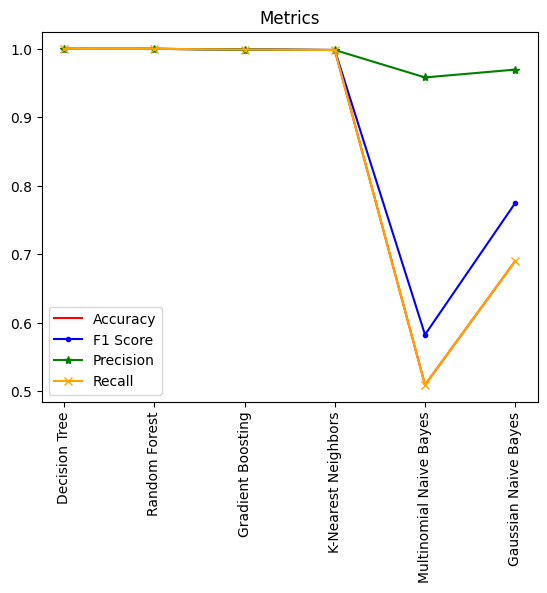

In [39]:
plt.figure()
plt.title('Metrics')
plt.plot(models, accuracy, color="red", marker=",", label="Accuracy")
plt.plot(models, f1, color="blue", marker=".", label="F1 Score")
plt.plot(models, precision, color="green", marker="*", label="Precision")
plt.plot(models, recall, color="orange", marker="x", label="Recall")
plt.xticks(rotation=90)
plt.legend()  
plt.show()

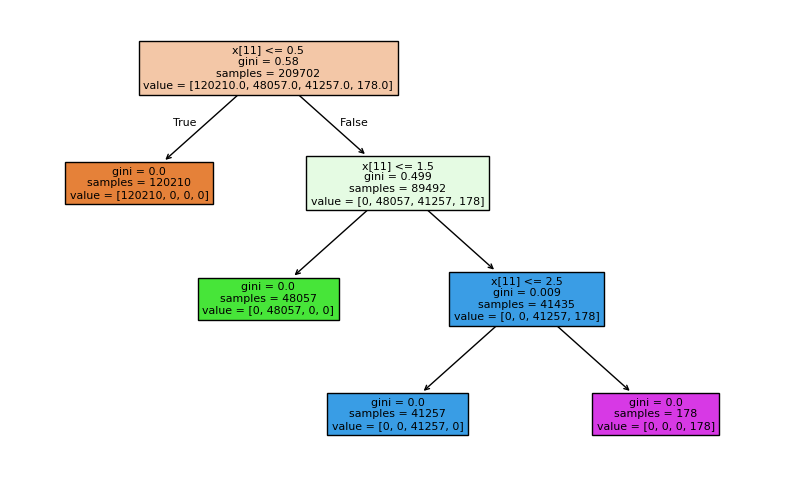

In [40]:

dt.fit(X_train, y_train)


plt.figure(figsize=(10, 6))
tree.plot_tree(dt, filled=True)
plt.show()
     


In [41]:
all_features_importances = {}

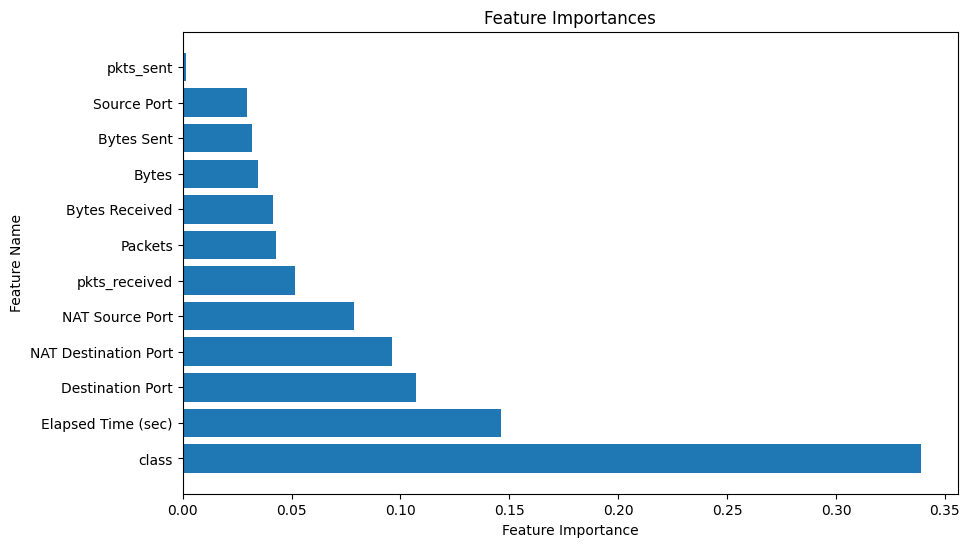

In [43]:

rf.fit(X_train, y_train)


feature_importances = rf.feature_importances_
feature_names = X_train.columns


features_named = dict(zip(feature_names, feature_importances))


all_features_importances["Random Forest"] = features_named


sorted_feature_importances = sorted(features_named.items(), key=lambda x: x[1], reverse=True)


sorted_feature_names = [x[0] for x in sorted_feature_importances]
sorted_importances = [x[1] for x in sorted_feature_importances]


plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, sorted_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Feature Importances')
plt.show()

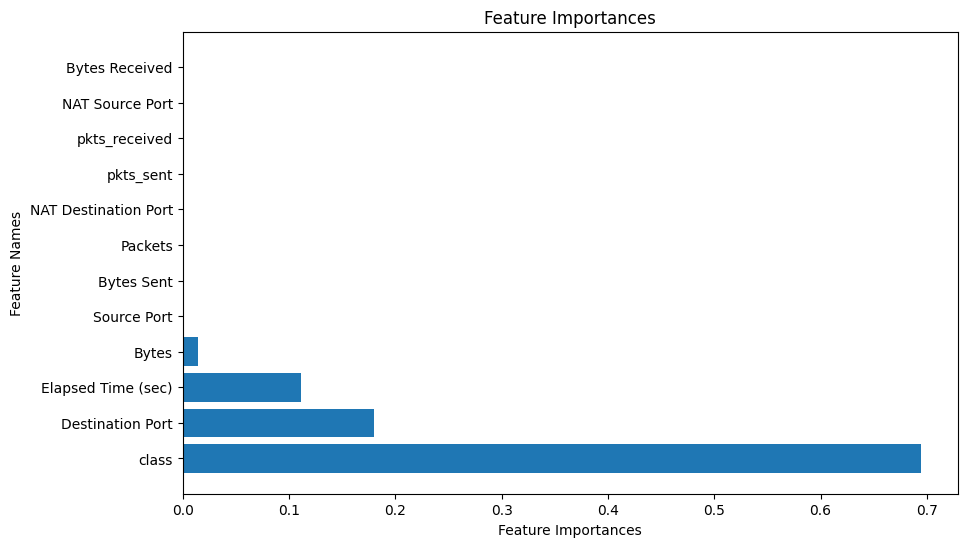

In [45]:

gb.fit(X_train, y_train)


feature_importances = gb.feature_importances_
feature_names = X_train.columns


features_named = dict(zip(feature_names, feature_importances))


all_features_importances["Gradient Boosting"] = features_named


sorted_feature_importances = sorted(features_named.items(), key=lambda x: x[1], reverse=True)


sorted_feature_names = [x[0] for x in sorted_feature_importances]
sorted_importances = [x[1] for x in sorted_feature_importances]


plt.figure(figsize=(10, 6))
plt.barh(sorted_feature_names, sorted_importances)
plt.xlabel('Feature Importances')
plt.ylabel('Feature Names')
plt.title('Feature Importances')
plt.show()

# Report and Final Thoughts: 
* Model Name 	Accuracy Score 	F1 Score 	Precision Score 	Recall Score
*  Decision Tree 	1.000000 	1.000000 	1.000000 	1.000000
*  Random Forest 	1.000000 	1.000000 	1.000000 	1.000000
*  Gradient Boosting 	0.998989 	0.998988 	0.998991 	0.998989
*  K-Nearest Neighbors 	0.998321 	0.998308 	0.998325 	0.998321
*  Multinomial Naive Bayes 	0.509518 	0.582754 	0.958295 	0.509518
*  Gaussian Naive Bayes 	0.690211 	0.774905 	0.969712 	0.690211*

### Decision tree ranks top amongst all other models 

# Feature
*  Class
*  Elapsed time (sec)
*  Destination port
*  NAT Source port
*  NAT Destination port

#### The feature importance aligns with what one would expect from a firewall rule. Depending on the elapsed time, the firewall may allow, drop, or deny a packet. For instance, unusually long processing times can indicate a potential attack or security breach. The destination port also serves as a possible indicator of compromise, as malicious activity can target vulnerable or open ports. Port scanning, for example, is commonly used by attackers to identify exploitable entry points. In such cases, dropping the packet is the recommended action.
